# Maximum Likelihood Estimation & Bayesian Thinking
### A from-first-principles review for quant trading interviews

> **Read me first.** This notebook is built as a *consolidation + drill* sheet. Every section follows the same rhythm: **WHY the idea exists → the math, derived step by step → code/visualization → a 🎯 interview-flag** telling you how often the idea shows up in quant interviews and how it tends to be asked.

MLE and Bayesian reasoning are two of the **most heavily tested probability topics** in quant trading interviews (Jane Street, Optiver, HRT, SIG, Citadel, Two Sigma, etc.). They show up as:

- "Here is some data / a sequence of coin flips — what's the most likely value of $p$?"
- "You see 3 heads in 5 flips. What's your estimate? Now I tell you the coin came from a bag of mostly-fair coins — does your answer change?"
- "Update your belief as new information arrives" (sequential / online reasoning — exactly how a trader updates a view as fills come in).

By the end you will be able to **derive** the standard estimators on a whiteboard, **explain the intuition** in one sentence, and **recognize** which framework an interviewer is fishing for.

---

## 0 · The one-paragraph map

There are two camps for answering "what is the parameter behind this data?"

| Camp | One-line philosophy | Core formula | Output |
|------|--------------------|--------------|--------|
| **Frequentist / MLE** | "The parameter is a *fixed unknown number*. Pick the value that makes the data I saw most probable." | maximize $P(\text{data}\mid\theta)$ | a single number $\hat\theta$ |
| **Bayesian** | "The parameter is *itself uncertain*. Start with a belief, then let data reshape it." | $P(\theta\mid\text{data})\propto P(\text{data}\mid\theta)\,P(\theta)$ | a whole *distribution* over $\theta$ |

MLE is the special case of Bayesian where you (a) use a flat prior and (b) collapse the posterior to its peak. So they are not rivals — they are nested. Knowing exactly how they connect is the answer that impresses interviewers.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats  # only for tidy reference curves; we derive everything by hand too

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

PALETTE = {
    "prior":      "steelblue",
    "likelihood": "darkorange",
    "posterior":  "tomato",
    "mle":        "mediumseagreen",
    "accent":     "navy",
}

rng = np.random.default_rng(7)

# numpy 2.0 renamed trapz -> trapezoid; keep one name that works on both
trapz = getattr(np, "trapezoid", None) or np.trapz

print("Environment ready.")

Environment ready.


## 1 · Likelihood vs Probability — the distinction interviewers love

This is the **#1 conceptual trap**. They sound identical in English; they are different *functions of different variables*.

Take a coin with unknown heads-probability $p$. Flip it once, observe $H$.

- **Probability** fixes the parameter, asks about data:
$$P(\text{data} = H \mid p) = p \qquad \text{($p$ is given; data varies)}$$
- **Likelihood** fixes the data, asks about the parameter:
$$\mathcal{L}(p \mid \text{data} = H) = p \qquad \text{(data is given; $p$ varies)}$$

The *numbers* look the same here, but the **meaning** is opposite. As a function of $p$, the likelihood is **not** a probability distribution — it does **not** integrate to 1 over $p$. It just measures "how well does this candidate $p$ explain what I actually saw?"

> **Key insight:** Probability runs *parameter → data*. Likelihood runs *data → parameter*. MLE = slide the parameter knob until the likelihood is as high as possible.

🎯 **Interview flag (VERY common):** If asked "what's the difference between likelihood and probability?", the crisp answer is: *"Same joint expression $P(\text{data}\mid\theta)$, but probability treats it as a function of the data with $\theta$ fixed, while likelihood treats it as a function of $\theta$ with the data fixed. The likelihood is not a density over $\theta$."* Say that and you've passed the screen.

---

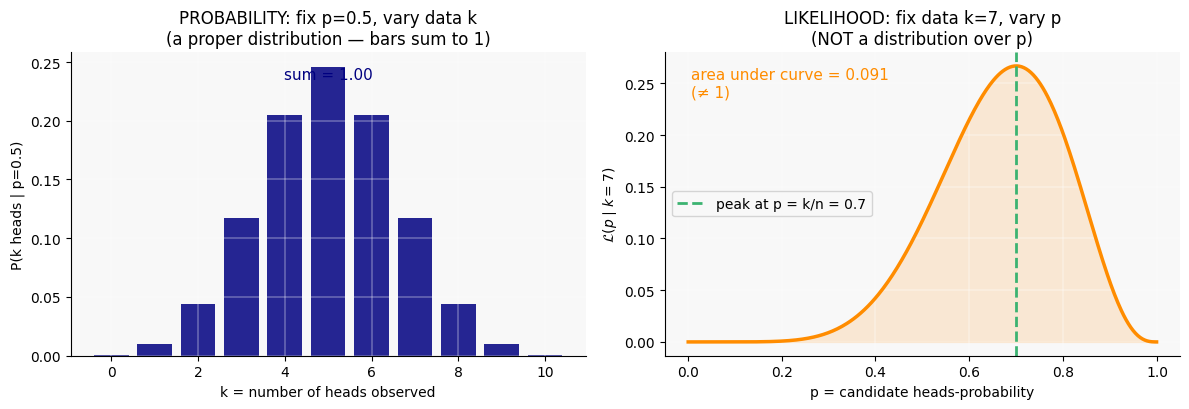

In [2]:
# Visualize the two readings of the SAME surface P(data | p) for n=10 flips.
n = 10
p_grid = np.linspace(0.001, 0.999, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# LEFT: Probability — fix p, vary the data (number of heads k)
p_fixed = 0.5
k_vals = np.arange(0, n + 1)
pmf = stats.binom.pmf(k_vals, n, p_fixed)
axes[0].bar(k_vals, pmf, color=PALETTE["accent"], alpha=0.85)
axes[0].set_title(f"PROBABILITY: fix p={p_fixed}, vary data k\n(a proper distribution — bars sum to 1)")
axes[0].set_xlabel("k = number of heads observed")
axes[0].set_ylabel("P(k heads | p=0.5)")
axes[0].grid(alpha=0.3)
axes[0].text(0.5, 0.95, f"sum = {pmf.sum():.2f}", transform=axes[0].transAxes,
             ha="center", va="top", fontsize=11, color=PALETTE["accent"])

# RIGHT: Likelihood — fix the data (say k=7), vary p
k_obs = 7
lik = stats.binom.pmf(k_obs, n, p_grid)
axes[1].plot(p_grid, lik, color=PALETTE["likelihood"], lw=2.5)
axes[1].fill_between(p_grid, lik, color=PALETTE["likelihood"], alpha=0.15)
axes[1].axvline(k_obs / n, color=PALETTE["mle"], ls="--", lw=2,
                label=f"peak at p = k/n = {k_obs/n:.1f}")
axes[1].set_title(f"LIKELIHOOD: fix data k={k_obs}, vary p\n(NOT a distribution over p)")
axes[1].set_xlabel("p = candidate heads-probability")
axes[1].set_ylabel(r"$\mathcal{L}(p \mid k=7)$")
axes[1].legend()
axes[1].grid(alpha=0.3)
area = trapz(lik, p_grid)
axes[1].text(0.05, 0.95, f"area under curve = {area:.3f}\n(≠ 1)", transform=axes[1].transAxes,
             ha="left", va="top", fontsize=11, color=PALETTE["likelihood"])

plt.tight_layout()
plt.show()

## 2 · Maximum Likelihood Estimation — the recipe

The MLE recipe is always the same four steps. Memorize it; it works for *any* model.

| Step | What you do | Why |
|------|-------------|-----|
| 1 | Write the **likelihood** $\mathcal{L}(\theta)=\prod_i P(x_i\mid\theta)$ | data points are independent → joint = product |
| 2 | Take the **log** → $\ell(\theta)=\sum_i \log P(x_i\mid\theta)$ | turns nasty products into friendly sums; $\log$ is monotone so the argmax is unchanged |
| 3 | **Differentiate** and set $\dfrac{d\ell}{d\theta}=0$ | the peak of a smooth hill has zero slope |
| 4 | **Solve** for $\hat\theta_{\text{MLE}}$ (check it's a max) | that's your estimate |

> **Key insight:** We maximize the **log**-likelihood, never the raw likelihood. Products of many small probabilities underflow to 0 on a computer and are painful by hand; sums of logs are stable and differentiate term-by-term. The location of the peak is identical because $\log$ is strictly increasing.

### 2.1 Worked example — the coin (Bernoulli)

Data: $n$ independent flips, $k$ heads. Each flip has $P(x_i\mid p)=p^{x_i}(1-p)^{1-x_i}$.

**Step 1 — likelihood:**
$$\mathcal{L}(p)=\prod_{i=1}^n p^{x_i}(1-p)^{1-x_i}=p^{\,k}(1-p)^{\,n-k}$$

The exponent on $p$ counts the heads, the exponent on $(1-p)$ counts the tails. That's the whole story of the data compressed into two numbers.

**Step 2 — log-likelihood:**
$$\ell(p)=k\log p+(n-k)\log(1-p)$$

**Step 3 — differentiate and set to zero:**
$$\frac{d\ell}{dp}=\frac{k}{p}-\frac{n-k}{1-p}=0$$

The first term is the "pull toward more heads," the second is the "pull toward more tails." The estimate sits where they balance.

**Step 4 — solve:**
$$k(1-p)=(n-k)p \;\Rightarrow\; k-kp=np-kp \;\Rightarrow\; \boxed{\hat p_{\text{MLE}}=\frac{k}{n}}$$

The most likely coin bias is just the **observed frequency of heads**. Beautifully obvious in hindsight — that's the mark of a good derivation.

🎯 **Interview flag (extremely common):** "I flip a coin $n$ times and see $k$ heads — MLE for $p$?" Answer instantly: $k/n$, and be ready to *derive* it in the four steps above. Follow-up they love: "what's the variance of this estimator?" → $\operatorname{Var}(\hat p)=\dfrac{p(1-p)}{n}$ (since $\hat p$ is a sample mean of Bernoullis).

---

In [3]:
# MLE for the coin, FROM SCRATCH (no scipy.optimize) — we both solve analytically
# and confirm by scanning the log-likelihood, recording a loss_history along a 1-D grid.

def bernoulli_log_likelihood(p, k, n):
    # Log-likelihood of seeing k heads in n flips for bias p. Vectorized over p.
    p = np.clip(p, 1e-12, 1 - 1e-12)  # guard the logs at the boundaries
    return k * np.log(p) + (n - k) * np.log(1 - p)

# --- synthetic data: a biased coin we secretly know is p_true = 0.7 ---
p_true = 0.70
n_flips = 40
flips = rng.random(n_flips) < p_true     # True = Heads
k_heads = int(flips.sum())
print(f"Observed: {k_heads} heads out of {n_flips} flips")

# --- analytic MLE ---
p_hat = k_heads / n_flips
print(f"Analytic MLE  p_hat = k/n = {p_hat:.4f}   (truth was {p_true})")

# --- 'training loop' = scan p over a grid, record the (negative) log-likelihood ---
p_scan = np.linspace(0.01, 0.99, 500)
loss_history = -bernoulli_log_likelihood(p_scan, k_heads, n_flips)  # NLL = the loss we minimize
p_hat_grid = p_scan[np.argmin(loss_history)]
print(f"Grid-search MLE          = {p_hat_grid:.4f}  (matches the formula ✔)")
print(f"Estimator std (theory)   = {np.sqrt(p_hat*(1-p_hat)/n_flips):.4f}")

Observed: 30 heads out of 40 flips
Analytic MLE  p_hat = k/n = 0.7500   (truth was 0.7)
Grid-search MLE          = 0.7504  (matches the formula ✔)
Estimator std (theory)   = 0.0685


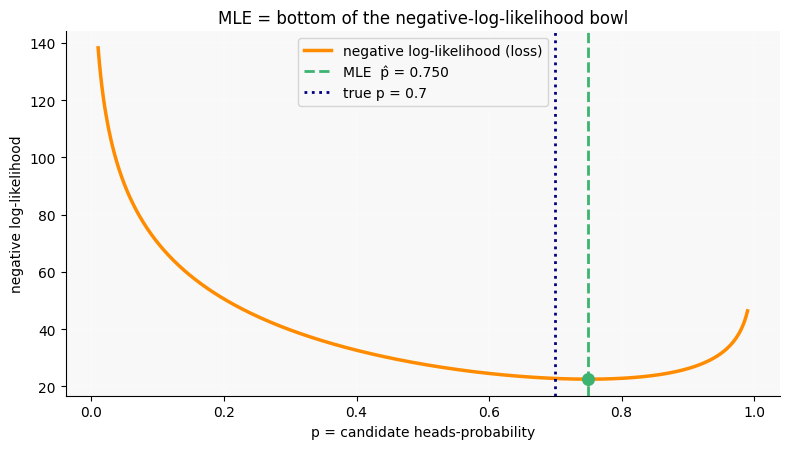

In [4]:
# Loss landscape: the negative log-likelihood is a clean 1-D bowl whose bottom is the MLE.
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(p_scan, loss_history, color=PALETTE["likelihood"], lw=2.5, label="negative log-likelihood (loss)")
ax.axvline(p_hat, color=PALETTE["mle"], ls="--", lw=2, label=f"MLE  p̂ = {p_hat:.3f}")
ax.axvline(p_true, color=PALETTE["accent"], ls=":", lw=2, label=f"true p = {p_true}")
ax.scatter([p_hat], [loss_history.min()], color=PALETTE["mle"], zorder=5, s=70)
ax.set_xlabel("p = candidate heads-probability")
ax.set_ylabel("negative log-likelihood")
ax.set_title("MLE = bottom of the negative-log-likelihood bowl")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Worked example — the Gaussian (the one quant interviews adore)

Data $x_1,\dots,x_n$ assumed i.i.d. $\mathcal{N}(\mu,\sigma^2)$. This is *the* canonical MLE derivation because returns are so often modeled as Gaussian.

Each point's density:
$$P(x_i\mid\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

**Log-likelihood** (sum the logs — the exponential melts away, which is *why* we log):
$$\ell(\mu,\sigma^2)=-\frac{n}{2}\log(2\pi)-\frac{n}{2}\log\sigma^2-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2$$

**Solve for $\mu$** (only the last term depends on it):
$$\frac{\partial\ell}{\partial\mu}=\frac{1}{\sigma^2}\sum_i (x_i-\mu)=0 \;\Rightarrow\; \boxed{\hat\mu=\frac{1}{n}\sum_i x_i=\bar x}$$

The MLE of the mean is the **sample mean**. The $\frac{1}{\sigma^2}$ factor scales the slope but can't move where it's zero, so $\sigma$ doesn't matter for locating $\hat\mu$.

**Solve for $\sigma^2$** (treat $v=\sigma^2$ as the variable):
$$\frac{\partial\ell}{\partial v}=-\frac{n}{2v}+\frac{1}{2v^2}\sum_i (x_i-\mu)^2=0 \;\Rightarrow\; \boxed{\hat\sigma^2=\frac{1}{n}\sum_i (x_i-\hat\mu)^2}$$

> **Key insight — the famous $\frac1n$ vs $\frac1{n-1}$ gotcha:** The MLE divides by $n$, **not** $n-1$. It is therefore **biased** — it systematically *underestimates* the variance, because it reuses $\bar x$ (fitted to the same data) instead of the true $\mu$, which makes the squared deviations a touch too small. The unbiased sample variance uses $n-1$ (Bessel's correction). MLE optimality and unbiasedness are **different goals**.

🎯 **Interview flag (classic, asked constantly):** "Derive the MLE for the mean and variance of a Gaussian." Then the gotcha: "Is the MLE variance biased?" → **Yes, it divides by $n$ and underestimates; the bias is a factor $\frac{n-1}{n}$.** Knowing *why* (degrees of freedom spent estimating the mean) is the differentiator.

---

In [5]:
# Gaussian MLE from scratch, plus a demonstration of the 1/n bias.
mu_true, sigma_true = 2.0, 1.5
n_samp = 30
data = rng.normal(mu_true, sigma_true, size=n_samp)

# closed-form MLEs
mu_hat = data.mean()
sigma2_mle = np.mean((data - mu_hat) ** 2)        # divide by n   -> MLE (biased)
sigma2_unb = np.sum((data - mu_hat) ** 2) / (n_samp - 1)  # divide by n-1 -> unbiased

print(f"mu_hat (sample mean)        = {mu_hat:.4f}   (true {mu_true})")
print(f"sigma^2 MLE     (÷ n)       = {sigma2_mle:.4f}")
print(f"sigma^2 unbiased(÷ n-1)     = {sigma2_unb:.4f}   (true {sigma_true**2:.4f})")

# Monte-Carlo proof that the ÷n estimator is biased low on average
trials = 20000
mle_vars, unb_vars = np.empty(trials), np.empty(trials)
for t in range(trials):
    s = rng.normal(mu_true, sigma_true, size=n_samp)
    m = s.mean()
    mle_vars[t] = np.mean((s - m) ** 2)
    unb_vars[t] = np.sum((s - m) ** 2) / (n_samp - 1)
print(f"\nOver {trials} simulations (true variance = {sigma_true**2:.3f}):")
print(f"  mean of ÷n  estimator = {mle_vars.mean():.4f}  <-- biased LOW")
print(f"  mean of ÷n-1 estimator = {unb_vars.mean():.4f}  <-- unbiased ✔")
print(f"  ratio mle/true = {mle_vars.mean()/sigma_true**2:.4f}  ≈ (n-1)/n = {(n_samp-1)/n_samp:.4f}")

mu_hat (sample mean)        = 2.0880   (true 2.0)
sigma^2 MLE     (÷ n)       = 1.6950
sigma^2 unbiased(÷ n-1)     = 1.7534   (true 2.2500)

Over 20000 simulations (true variance = 2.250):
  mean of ÷n  estimator = 2.1725  <-- biased LOW
  mean of ÷n-1 estimator = 2.2474  <-- unbiased ✔
  ratio mle/true = 0.9655  ≈ (n-1)/n = 0.9667


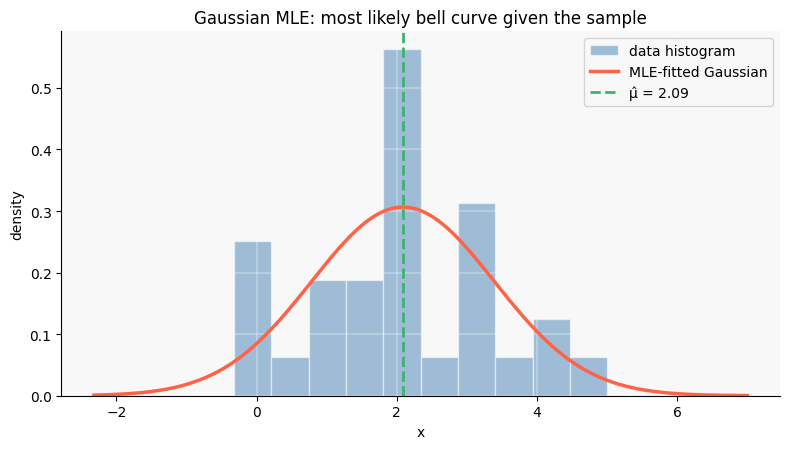

In [6]:
# Picture: the fitted Gaussian sitting on top of the data histogram.
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(data, bins=10, density=True, color="steelblue", alpha=0.5,
        edgecolor="white", label="data histogram")
xx = np.linspace(data.min() - 2, data.max() + 2, 300)
ax.plot(xx, stats.norm.pdf(xx, mu_hat, np.sqrt(sigma2_mle)),
        color=PALETTE["posterior"], lw=2.5, label="MLE-fitted Gaussian")
ax.axvline(mu_hat, color=PALETTE["mle"], ls="--", lw=2, label=f"μ̂ = {mu_hat:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.set_title("Gaussian MLE: most likely bell curve given the sample")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3 · Bayesian thinking — beliefs that update

MLE gives a single point. But a trader rarely *knows* a parameter — they hold a **belief** with uncertainty, and revise it as data arrives. That is exactly Bayes' theorem.

$$\underbrace{P(\theta\mid \text{data})}_{\textbf{posterior}}=\frac{\overbrace{P(\text{data}\mid\theta)}^{\textbf{likelihood}}\;\overbrace{P(\theta)}^{\textbf{prior}}}{\underbrace{P(\text{data})}_{\textbf{evidence}}}$$

Read it as an **update rule**:

| Term | Plain meaning | Trader's analogy |
|------|---------------|------------------|
| **Prior** $P(\theta)$ | what you believed *before* the data | your view on a coin/edge before today's flips/fills |
| **Likelihood** $P(\text{data}\mid\theta)$ | how well each $\theta$ explains the new data | the signal in today's observations |
| **Posterior** $P(\theta\mid\text{data})$ | your *updated* belief | your revised view |
| **Evidence** $P(\text{data})$ | normalizer $\int P(\text{data}\mid\theta)P(\theta)\,d\theta$ | just makes the posterior integrate to 1 |

Because the evidence doesn't depend on $\theta$, the working form everyone uses is:
$$\boxed{\text{posterior}\;\propto\;\text{likelihood}\times\text{prior}}$$

> **Key insight:** MLE listens *only* to the likelihood. Bayes multiplies the likelihood by a prior, so it refuses to be stampeded by a tiny sample. "3 heads in 3 flips → $\hat p=1$" is the MLE; a Bayesian with a sane prior says "probably biased, but I won't bet it's a 100% coin yet."

🎯 **Interview flag (the most famous Bayes question of all):** the **disease-test / false-positive paradox**. "A test is 99% accurate, disease prevalence 1%, you test positive — what's $P(\text{sick})$?" The answer is shockingly low (~50%) because the **prior** (rarity) dominates. We work it below.

---

In [7]:
# The classic base-rate problem, computed explicitly so you can narrate it on a whiteboard.
prevalence   = 0.01   # P(disease)  -- the PRIOR
sensitivity  = 0.99   # P(+ | disease)        true-positive rate
specificity  = 0.99   # P(- | healthy)        -> false-positive rate = 0.01

p_pos_given_sick    = sensitivity
p_pos_given_healthy = 1 - specificity

# Total probability of a positive test (the evidence / normalizer)
p_pos = p_pos_given_sick * prevalence + p_pos_given_healthy * (1 - prevalence)

# Bayes
posterior_sick = p_pos_given_sick * prevalence / p_pos
print(f"P(positive test)          = {p_pos:.4f}")
print(f"P(disease | positive)     = {posterior_sick:.4f}  <-- only ~{posterior_sick*100:.0f}%!")
print(f"\nIntuition with 10,000 people:")
print(f"  {int(prevalence*10000):>4d} truly sick  -> {int(prevalence*10000*sensitivity)} test positive (true positives)")
print(f"  {int((1-prevalence)*10000):>4d} healthy    -> {int((1-prevalence)*10000*p_pos_given_healthy)} test positive (FALSE positives)")
print(f"  Among all positives, the true positives are the minority -> posterior ≈ 50%.")

P(positive test)          = 0.0198
P(disease | positive)     = 0.5000  <-- only ~50%!

Intuition with 10,000 people:
   100 truly sick  -> 99 test positive (true positives)
  9900 healthy    -> 99 test positive (FALSE positives)
  Among all positives, the true positives are the minority -> posterior ≈ 50%.


## 4 · Conjugate priors: the Beta–Binomial (the Bayesian coin)

Doing Bayes usually means a hard integral for the evidence. **Conjugate priors** are the magic shortcut: pick a prior whose shape is preserved by the update, so the posterior is the *same family* with updated parameters — no integral needed. For a coin/Bernoulli, the conjugate prior is the **Beta distribution**.

$$\text{Beta}(p\mid\alpha,\beta)\;\propto\;p^{\alpha-1}(1-p)^{\beta-1}$$

Think of $\alpha-1$ as "**heads I've imagined seeing before any data**" and $\beta-1$ as imagined tails — the prior is *pseudo-counts* encoding your starting belief. $\text{Beta}(1,1)$ is flat (totally agnostic).

Now multiply by the Bernoulli likelihood $p^{k}(1-p)^{n-k}$:
$$\text{posterior}\propto \underbrace{p^{k}(1-p)^{n-k}}_{\text{likelihood}}\cdot \underbrace{p^{\alpha-1}(1-p)^{\beta-1}}_{\text{prior}}=p^{\,(\alpha+k)-1}(1-p)^{\,(\beta+n-k)-1}$$

which is just $\text{Beta}(\alpha+k,\ \beta+n-k)$. The update is **adorably simple**:

$$\boxed{\alpha \leftarrow \alpha + (\text{heads}),\qquad \beta \leftarrow \beta + (\text{tails})}$$

> **Key insight:** Bayesian updating with a conjugate prior is *literally just counting*. You add observed heads to $\alpha$ and observed tails to $\beta$. The posterior **mean** is $\dfrac{\alpha+k}{\alpha+\beta+n}$ — the data frequency $k/n$ *shrunk toward the prior mean*. With lots of data the prior washes out and you recover the MLE $k/n$.

🎯 **Interview flag (common):** "What's a conjugate prior, and why use one?" → *"A prior that keeps the posterior in the same family, so updating is closed-form parameter arithmetic instead of an integral. Beta is conjugate to Bernoulli/Binomial, Gamma to Poisson, Normal to Normal."* Also be ready for **Laplace's rule of succession**: with a flat $\text{Beta}(1,1)$ prior and $k$ heads in $n$, the posterior-mean estimate is $\frac{k+1}{n+2}$ — note how it never collapses to 0 or 1.

---

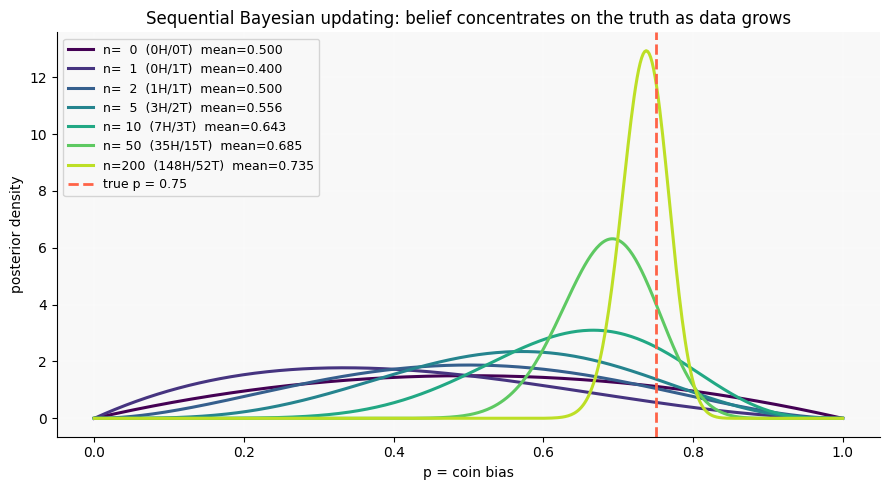

In [8]:
# Sequential Bayesian updating of a coin's bias — watch belief sharpen flip by flip.
def beta_pdf(p, a, b):
    return stats.beta.pdf(p, a, b)

p_true_coin = 0.75
alpha0, beta0 = 2.0, 2.0          # prior: weakly believe it's near-fair (a gentle hump at 0.5)
p_axis = np.linspace(0, 1, 500)

# generate a stream of flips, snapshot the posterior at chosen sample sizes
snapshots = [0, 1, 2, 5, 10, 50, 200]
stream = (rng.random(max(snapshots)) < p_true_coin).astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(snapshots)))
for snap, c in zip(snapshots, colors):
    heads = int(stream[:snap].sum())
    tails = snap - heads
    a_post, b_post = alpha0 + heads, beta0 + tails
    post_mean = a_post / (a_post + b_post)
    ax.plot(p_axis, beta_pdf(p_axis, a_post, b_post), color=c, lw=2.2,
            label=f"n={snap:>3d}  ({heads}H/{tails}T)  mean={post_mean:.3f}")

ax.axvline(p_true_coin, color=PALETTE["posterior"], ls="--", lw=2, label=f"true p = {p_true_coin}")
ax.set_xlabel("p = coin bias")
ax.set_ylabel("posterior density")
ax.set_title("Sequential Bayesian updating: belief concentrates on the truth as data grows")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

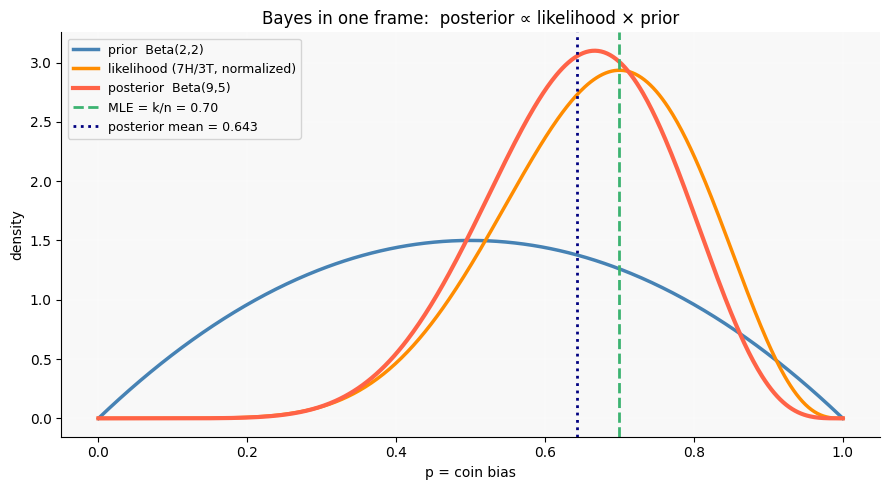

MLE point estimate     : 0.700  (ignores prior)
Posterior mean estimate: 0.643  (pulled toward prior mean 0.5 -> 'shrinkage')


In [9]:
# The money picture: PRIOR x LIKELIHOOD = POSTERIOR, on one set of axes.
heads, tails = 7, 3                 # observed: 7 heads in 10
n_obs = heads + tails
a_pr, b_pr = 2.0, 2.0               # prior Beta(2,2)

prior      = beta_pdf(p_axis, a_pr, b_pr)
likelihood = stats.binom.pmf(heads, n_obs, p_axis)      # as a function of p
posterior  = beta_pdf(p_axis, a_pr + heads, b_pr + tails)

# scale likelihood just for visual comparison (its area isn't 1 in p)
likelihood_scaled = likelihood / trapz(likelihood, p_axis)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p_axis, prior, color=PALETTE["prior"], lw=2.5, label="prior  Beta(2,2)")
ax.plot(p_axis, likelihood_scaled, color=PALETTE["likelihood"], lw=2.5,
        label="likelihood (7H/3T, normalized)")
ax.plot(p_axis, posterior, color=PALETTE["posterior"], lw=3, label="posterior  Beta(9,5)")

mle  = heads / n_obs
pm   = (a_pr + heads) / (a_pr + b_pr + n_obs)
ax.axvline(mle, color=PALETTE["mle"], ls="--", lw=2, label=f"MLE = k/n = {mle:.2f}")
ax.axvline(pm,  color=PALETTE["accent"], ls=":", lw=2, label=f"posterior mean = {pm:.3f}")

ax.set_xlabel("p = coin bias")
ax.set_ylabel("density")
ax.set_title("Bayes in one frame:  posterior ∝ likelihood × prior")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"MLE point estimate     : {mle:.3f}  (ignores prior)")
print(f"Posterior mean estimate: {pm:.3f}  (pulled toward prior mean 0.5 -> 'shrinkage')")

## 5 · MAP vs MLE — where the two worlds meet

The **MAP** (Maximum A Posteriori) estimate is the *peak* of the posterior — the Bayesian's single best guess if forced to name one number:
$$\hat\theta_{\text{MAP}}=\arg\max_\theta \;P(\theta\mid\text{data})=\arg\max_\theta\;\underbrace{\log P(\text{data}\mid\theta)}_{\text{log-likelihood}}+\underbrace{\log P(\theta)}_{\text{log-prior}}$$

Stare at that sum. The first term is exactly what **MLE** maximizes. The second term — the **log-prior — acts as a penalty/regularizer**. This is the bridge between the two cultures:

| | MLE | MAP |
|---|-----|-----|
| Objective | $\log P(\text{data}\mid\theta)$ | $\log P(\text{data}\mid\theta)+\log P(\theta)$ |
| Prior | none (equivalently, flat) | yes |
| As data → ∞ | — | converges to MLE (prior washes out) |

> **Key insight (a favorite "aha"):** **Ridge / L2 regularization = MAP with a Gaussian prior**, and **Lasso / L1 = MAP with a Laplace prior**. Penalizing big weights is *mathematically identical* to saying "a priori I believe the weights are small." If you can state this, you've connected MLE, Bayes, and regularization in one breath — exactly the kind of synthesis senior interviewers probe for.

🎯 **Interview flag:** "Difference between MLE and MAP?" → *"MAP adds a log-prior term to the log-likelihood; with a flat prior MAP = MLE, and with infinite data they agree because the likelihood overwhelms the prior."* Bonus: "How does MAP relate to regularization?" → the L2/L1 ↔ Gaussian/Laplace correspondence above.

---

In [10]:
# Show MLE vs MAP diverging on SMALL data and converging on LARGE data.
def coin_estimates(heads, tails, a_pr=5.0, b_pr=5.0):
    n = heads + tails
    mle = heads / n if n else np.nan
    map_est = (a_pr + heads - 1) / (a_pr + b_pr + n - 2)   # mode of Beta(a+h, b+t)
    post_mean = (a_pr + heads) / (a_pr + b_pr + n)
    return mle, map_est, post_mean

print("Strong prior Beta(5,5) (i.e. 'I lean fair'); TRUE p = 0.8\n")
print(f"{'n flips':>8} {'MLE k/n':>10} {'MAP':>10} {'post.mean':>10}")
p_true_c = 0.8
for n in [2, 5, 10, 50, 500]:
    s = (rng.random(n) < p_true_c).astype(int)
    h = int(s.sum()); t = n - h
    mle, mp, pm = coin_estimates(h, t)
    print(f"{n:>8} {mle:>10.3f} {mp:>10.3f} {pm:>10.3f}")
print("\nSmall n: MAP/posterior-mean sit between data and prior (0.5) -> robust to noise.")
print("Large n: all three estimates collide on the truth -> the prior has washed out.")

Strong prior Beta(5,5) (i.e. 'I lean fair'); TRUE p = 0.8

 n flips    MLE k/n        MAP  post.mean
       2      1.000      0.600      0.583
       5      1.000      0.692      0.667
      10      0.700      0.611      0.600
      50      0.840      0.793      0.783
     500      0.754      0.750      0.749

Small n: MAP/posterior-mean sit between data and prior (0.5) -> robust to noise.
Large n: all three estimates collide on the truth -> the prior has washed out.


## 6 · Interactive: feel how the prior fights the data

Drag the sliders. Watch how a **strong prior** resists a small contradicting sample, and how **more data** eventually overrules any prior. This is the single most important *intuition* to carry into the interview: *the posterior is a tug-of-war between prior conviction and evidence weight.*

In [11]:
# If ipywidgets is available you get sliders; otherwise we render a static 2x2 grid.
def show_update(prior_strength=4.0, prior_mean=0.5, n_flips=10, observed_freq=0.8):
    a_pr = prior_strength * prior_mean
    b_pr = prior_strength * (1 - prior_mean)
    heads = int(round(observed_freq * n_flips))
    tails = n_flips - heads

    prior     = beta_pdf(p_axis, a_pr, b_pr)
    posterior = beta_pdf(p_axis, a_pr + heads, b_pr + tails)
    lik       = stats.binom.pmf(heads, n_flips, p_axis)
    lik       = lik / trapz(lik, p_axis)

    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.plot(p_axis, prior,     color=PALETTE["prior"],      lw=2.5, label=f"prior Beta({a_pr:.1f},{b_pr:.1f})")
    ax.plot(p_axis, lik,       color=PALETTE["likelihood"], lw=2.5, label=f"likelihood ({heads}H/{tails}T)")
    ax.plot(p_axis, posterior, color=PALETTE["posterior"],  lw=3,   label="posterior")
    ax.axvline(heads/n_flips, color=PALETTE["mle"], ls="--", lw=1.8, label=f"MLE={heads/n_flips:.2f}")
    pm = (a_pr+heads)/(a_pr+b_pr+n_flips)
    ax.axvline(pm, color=PALETTE["accent"], ls=":", lw=1.8, label=f"post.mean={pm:.2f}")
    ax.set_xlabel("p"); ax.set_ylabel("density")
    ax.set_title("Prior vs Likelihood tug-of-war")
    ax.legend(fontsize=8.5); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact, FloatSlider, IntSlider
    interact(show_update,
             prior_strength=FloatSlider(value=4,  min=0.1, max=60, step=0.5, description="prior strength"),
             prior_mean=FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05, description="prior mean"),
             n_flips=IntSlider(value=10, min=1, max=300, step=1, description="n flips"),
             observed_freq=FloatSlider(value=0.8, min=0.0, max=1.0, step=0.05, description="obs heads freq"))
except Exception as e:
    print("ipywidgets unavailable — static snapshots instead:\n")
    for ps, nf in [(2, 5), (40, 5), (2, 200), (40, 200)]:
        print(f"prior_strength={ps}, n_flips={nf}:")
        show_update(prior_strength=ps, n_flips=nf)

interactive(children=(FloatSlider(value=4.0, description='prior strength', max=60.0, min=0.1, step=0.5), Float…

## 7 · Interview question bank — with reference answers

Work each one *before* expanding the answer. These are paraphrases of questions actually used at top quant shops.

---

**Q1. (warm-up) You flip a coin 10 times and get 8 heads. What is the MLE of $p$? Would you bet the coin lands heads 80% of the time?**

<details><summary>Reference answer</summary>

MLE is $k/n = 8/10 = 0.8$. But I would *not* confidently bet 80%: the sample is tiny, so the estimator has large variance, $\operatorname{Var}(\hat p)=p(1-p)/n \approx 0.016$, i.e. std $\approx 0.13$. A 95% interval is roughly $0.8 \pm 0.25$. A Bayesian with a mild fair-coin prior $\text{Beta}(2,2)$ gives posterior mean $\frac{2+8}{4+10}=0.71$, already shrinking the estimate toward fair. **Point estimate ≠ certainty** — quantify the uncertainty.
</details>

---

**Q2. (the base-rate classic) A disease affects 1 in 1000. A test is 99% sensitive and 99% specific. You test positive. Probability you're actually sick?**

<details><summary>Reference answer</summary>

$$P(\text{sick}\mid +)=\frac{0.99\cdot 0.001}{0.99\cdot 0.001+0.01\cdot 0.999}=\frac{0.00099}{0.00099+0.00999}\approx 0.090.$$
About **9%**. The rare prior dominates: false positives from the huge healthy population swamp the few true positives. *Always ask for the base rate.*
</details>

---

**Q3. Derive the MLE of $\lambda$ for i.i.d. data from a Poisson$(\lambda)$.**

<details><summary>Reference answer</summary>

$P(x_i\mid\lambda)=\dfrac{\lambda^{x_i}e^{-\lambda}}{x_i!}$. Log-likelihood $\ell=\sum_i(x_i\log\lambda-\lambda-\log x_i!)$. Then $\dfrac{d\ell}{d\lambda}=\dfrac{\sum x_i}{\lambda}-n=0\Rightarrow \hat\lambda=\bar x$. The MLE rate is just the **sample mean** of the counts. (Same flavor as Bernoulli/Gaussian — set $\frac{d\ell}{d\theta}=0$.)
</details>

---

**Q4. For i.i.d. Exponential$(\lambda)$ data with density $\lambda e^{-\lambda x}$, find the MLE of $\lambda$.**

<details><summary>Reference answer</summary>

$\ell=\sum_i(\log\lambda-\lambda x_i)=n\log\lambda-\lambda\sum x_i$. $\dfrac{d\ell}{d\lambda}=\dfrac{n}{\lambda}-\sum x_i=0\Rightarrow \hat\lambda=\dfrac{1}{\bar x}$. The rate is the **reciprocal of the sample mean** (mean inter-arrival time → arrival rate). Common in market-microstructure / order-arrival questions.
</details>

---

**Q5. Why maximize the *log*-likelihood instead of the likelihood itself?**

<details><summary>Reference answer</summary>

Three reasons: (1) $\log$ is strictly increasing, so the argmax is unchanged; (2) it turns a product over data points into a sum, which differentiates term-by-term and matches the i.i.d. structure; (3) numerical stability — a product of thousands of small probabilities underflows to 0 in floating point, whereas a sum of logs does not.
</details>

---

**Q6. What's the difference between MLE and MAP? When are they equal?**

<details><summary>Reference answer</summary>

MAP maximizes log-likelihood **plus** a log-prior; MLE maximizes log-likelihood alone. They coincide when the prior is flat (uniform), and they converge asymptotically as $n\to\infty$ because the likelihood term grows with $n$ while the prior term stays fixed. Bonus: a Gaussian prior makes MAP equal to **L2-regularized** (ridge) estimation; a Laplace prior gives **L1** (lasso).
</details>

---

**Q7. I see 3 heads in 3 flips. MLE says $p=1$. Is the coin definitely two-headed? How would a Bayesian answer?**

<details><summary>Reference answer</summary>

MLE $=3/3=1$ is the *overfitting trap* of small samples — it declares certainty from 3 data points. A Bayesian with $\text{Beta}(1,1)$ prior gets posterior $\text{Beta}(4,1)$, mean $4/5=0.8$, and assigns **nonzero probability to $p<1$** — it won't claim the coin can never land tails. This is **Laplace's rule of succession**: estimate $\frac{k+1}{n+2}=\frac{4}{5}$. Great illustration of why priors regularize.
</details>

---

**Q8. Is the MLE of the Gaussian variance biased? By how much?**

<details><summary>Reference answer</summary>

Yes. $\hat\sigma^2_{\text{MLE}}=\frac1n\sum(x_i-\bar x)^2$ has expectation $\frac{n-1}{n}\sigma^2$, so it underestimates by the factor $\frac{n-1}{n}$. Cause: we "spent" one degree of freedom estimating $\bar x$ from the same data, shrinking the deviations. Dividing by $n-1$ (Bessel) restores unbiasedness. Note MLE is still *consistent* — the bias vanishes as $n\to\infty$.
</details>

---

**Q9. You're updating a probability online as data streams in. How do MLE and Bayes differ operationally?**

<details><summary>Reference answer</summary>

With a conjugate prior, Bayes is **naturally online/recursive**: today's posterior is tomorrow's prior, and updating is just incrementing $\alpha,\beta$ (counts). MLE must in principle refit on all data, though for exponential-family models it reduces to maintaining sufficient statistics (e.g. running sum and count). Bayes additionally carries a full uncertainty distribution at every step — useful for sizing bets (cf. Kelly / Thompson sampling).
</details>

---

🎯 **Meta-tip:** When an interviewer hands you data and asks "what's your estimate?", *always clarify the framing*: "Do you want the MLE point estimate, or should I incorporate a prior?" That single question signals you understand both worlds.

---

## 8 · Summary

| Concept | Key Idea |
|---------|----------|
| **Likelihood vs probability** | Same expression $P(\text{data}\mid\theta)$; probability fixes $\theta$ & varies data, likelihood fixes data & varies $\theta$. Likelihood is **not** a density over $\theta$. |
| **MLE recipe** | Write $\mathcal L$ → take $\log$ → set $\frac{d\ell}{d\theta}=0$ → solve. Maximize the value of $\theta$ that best explains the observed data. |
| **MLE: Bernoulli** | $\hat p = k/n$ (observed frequency); $\operatorname{Var}(\hat p)=p(1-p)/n$. |
| **MLE: Gaussian** | $\hat\mu=\bar x$; $\hat\sigma^2=\frac1n\sum(x_i-\bar x)^2$ — **biased low** (÷n, not ÷(n−1)). |
| **MLE: Poisson / Exponential** | $\hat\lambda=\bar x$ (Poisson); $\hat\lambda=1/\bar x$ (Exponential). |
| **Why log-likelihood** | Monotone (same argmax), turns products→sums, numerically stable. |
| **Bayes' theorem** | posterior ∝ likelihood × prior; the evidence just normalizes. |
| **Base-rate fallacy** | A positive test on a rare condition can still mean low $P(\text{sick})$ — the prior dominates. |
| **Conjugate prior (Beta–Binomial)** | Posterior stays Beta: $\alpha\!\leftarrow\!\alpha+\text{heads}$, $\beta\!\leftarrow\!\beta+\text{tails}$. Updating = counting. |
| **Posterior mean / shrinkage** | $\frac{\alpha+k}{\alpha+\beta+n}$: data frequency shrunk toward prior; Laplace rule $\frac{k+1}{n+2}$. |
| **MAP vs MLE** | MAP = MLE + log-prior. Equal under a flat prior or as $n\to\infty$. |
| **Regularization link** | L2 ⇔ Gaussian prior, L1 ⇔ Laplace prior (MAP view). |
| **Interview reflex** | Quantify uncertainty, ask for the base rate, and clarify MLE-vs-prior framing. |

---

**You can now:** derive the standard MLEs on a whiteboard, explain likelihood vs probability in one sentence, run a Bayesian update by hand, and connect MLE → MAP → regularization. That trio of skills covers the large majority of probability-estimation questions in quant trading interviews. Good luck! 🎯